### Imports

In [2]:
# Imports
import torch
from typing import List, Tuple
from dataclasses import dataclass
import signatory

import numpy as np
import torch
import pickle
import os
from pathlib import Path
import bz2
import pandas as pd
import plotly.io as pio
pio.templates.default = 'plotly_white'
from minisom import MiniSom
from collections import Counter
from datetime import datetime
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,accuracy_score,jaccard_score
from scipy.optimize import linear_sum_assignment
from sklearn.linear_model import Lasso
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import sys
# This is need to get the imports from SIGSOM and jump-models
sys.path.insert(0, os.path.abspath('../'))
# helper functions
from SIGSOM.sigsom.utils.helpers import logger, SOMParams
# signature transforms
import SIGSOM.sigsom.signatures.signature_transforms as st
# som
from SIGSOM.sigsom.som.som import SOM
from SIGSOM.sigsom.som.som_mahalanobis import SOMM
from SIGSOM.sigsom.som.adapted_som import GSOMM

### Mulitvariate Cryptos

In [3]:
def rolling_window1(x: torch.Tensor, window: int) -> torch.Tensor:
    N = (x.shape[0]-1) // (window-1)
    result = torch.empty((N, window, x.shape[1]))
    for i in range(N):
        if i == 0:
            result[i, :, :] = x[0:window, :]
        else:
            result[i, :, :] = x[(i*(window))-i: (window*(i+1))-i,:]

    return result

In [4]:
file_path1 = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\data\ohlcv_data\ohlcv_data\ohlcv_data\hdp_rest_PERPETUAL_BINANCE_PERPETUAL_BTC-USDT_20220101_20231006.pbz2"
file_path2 = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\data\ohlcv_data\ohlcv_data\ohlcv_data\hdp_rest_PERPETUAL_BINANCE_PERPETUAL_ETH-USDT_20220101_20231006.pbz2"
file_path3 = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\data\ohlcv_data\ohlcv_data\ohlcv_data\hdp_rest_PERPETUAL_BINANCE_PERPETUAL_ADA-USDT_20220101_20231006.pbz2"

raw_data1 = st.load_pbz2(file_path1)
raw_data2 = st.load_pbz2(file_path2)
raw_data3 = st.load_pbz2(file_path3)

raw_data1['datetime']= raw_data1.index
raw_data1['datetime'] = raw_data1['datetime'].dt.tz_localize(None)

raw_data2['datetime']= raw_data2.index
raw_data2['datetime'] = raw_data2['datetime'].dt.tz_localize(None)

raw_data3['datetime']= raw_data3.index
raw_data3['datetime'] = raw_data3['datetime'].dt.tz_localize(None)

# Assuming st.load_pbz2 loads the data into a pandas DataFrame
def resample_data(data, resample_rule='5T', start_date=None, end_offset_years=2, price_column='close'):
    # Convert the 'datetime' column to datetime format
    data['datetime'] = pd.to_datetime(data['datetime'])
    
    # Set 'datetime' as the index
    data.set_index('datetime', inplace=True)
    
    # Define the end date as the given offset from the start date
    end_date = pd.to_datetime(start_date) + pd.DateOffset(years=end_offset_years)
    
    # Filter data for the defined period starting from start_date
    data = data.loc[start_date:end_date]
    
    # Resample and aggregate
    resampled_data = data.resample(resample_rule).agg({
        price_column: 'last',  # Last price in the resample window
    })
    
    # Handle missing data by forward filling
    resampled_data.ffill(inplace=True)
    
    return resampled_data

# Perform resampling on the loaded data
start_date = '2022-01-01'  # Define start date

# Resample the data
resampled_data1 = resample_data(raw_data1, resample_rule='5T', start_date=start_date, price_column='close')
resampled_data2 = resample_data(raw_data2, resample_rule='5T', start_date=start_date, price_column='close')
resampled_data3 = resample_data(raw_data3, resample_rule='5T', start_date=start_date, price_column='close')

resampled_data1 = resampled_data1[:185018]
resampled_data2 = resampled_data2[:185018]
resampled_data3 = resampled_data3[:185018]

# Check Shapes
print(resampled_data1.shape)
print(resampled_data2.shape)
print(resampled_data3.shape)

# Normalize and window

data_5min_1 = resampled_data1.values 
data_5min_1 = torch.tensor(data_5min_1, dtype=torch.float32) 
data_5min_1 = rolling_window1(data_5min_1, window=96*10)
data_5min_1 = data_5min_1 - data_5min_1[:,0:1]
data_5min_1 /= torch.std(data_5min_1, dim=1, keepdim=True)

data_5min_2 = resampled_data2.values 
data_5min_2 = torch.tensor(data_5min_2, dtype=torch.float32) 
data_5min_2 = rolling_window1(data_5min_2, window=96*10)
data_5min_2 = data_5min_2 - data_5min_2[:,0:1]
data_5min_2 /= torch.std(data_5min_2, dim=1, keepdim=True)

data_5min_3 = resampled_data3.values 
data_5min_3 = torch.tensor(data_5min_3, dtype=torch.float32) 
data_5min_3 = rolling_window1(data_5min_3, window=96*10)
data_5min_3 = data_5min_3 - data_5min_3[:,0:1]
data_5min_3 /= torch.std(data_5min_3, dim=1, keepdim=True)

# Concatenate
multivariate_path=torch.cat([data_5min_3[:],data_5min_2[:],data_5min_1[:]], dim=2)
multivariate_path.shape

# Scale the mulitvaraite path
data_min = multivariate_path.min(dim=0, keepdim=True)[0].min(dim=1, keepdim=True)[0]  # Global minimum per feature
data_max = multivariate_path.max(dim=0, keepdim=True)[0].max(dim=1, keepdim=True)[0]  # Global maximum per feature

# Apply Min-Max scaling: (data - min) / (max - min)
scaled_data = (multivariate_path - data_min) / (data_max - data_min)

# Check the range of the scaled data to confirm it's between 0 and 1
scaled_data_min = scaled_data.min().item()
scaled_data_max = scaled_data.max().item()

scaled_data_min, scaled_data_max

print(scaled_data.shape)

(185018, 1)
(185018, 1)
(185018, 1)
torch.Size([192, 960, 3])


### Singature and Post-Scaling

In [5]:
import torch
import math
from sympy import mobius, divisors

# Augmentations
augmentations = [
    (st.lead_lag_transform, {}),
]

# Transforms
transforms = [(st.log_singature, {"depth": 3, "basepoint": False})]

# Function to calculate the number of terms at a given depth using the Lie bracket formula
def num_terms_at_depth(d, n):
    """
    Compute the number of terms in the log signature at depth n using the given formula.
    
    Args:
    - d: Dimension of the input path.
    - n: Depth level.

    Returns:
    - Number of log signature terms at depth n.
    """
    result = 0
    for m in divisors(n):
        result += mobius(m) * d**(n // m)
    return result // n

# Function to rescale signature terms by the factorial of the depth level
def rescale_signature_by_factorial(signature, dimension, depth):
    """
    Multiplies the terms in the signature by the factorial of their respective depth level.
    Args:
    - signature: The signature tensor.
    - dimension: The number of input dimensions.
    - depth: The maximum depth of the signature.

    Returns:
    - Rescaled signature (factorial-weighted by depth level).
    """
    rescaled_signature = []
    current_index = 0

    for d in range(1, depth + 1):
        # Calculate the number of terms at this depth level
        n_terms_at_depth_d = num_terms_at_depth(dimension, d)
        # print(n_terms_at_depth_d)
        # print(dimension,d)
        # Compute factorial of the current depth level
        depth_factorial = math.factorial(d)

        # Extract the terms for the current depth and multiply by the depth factorial
        terms_at_depth_d = signature[..., current_index:current_index + n_terms_at_depth_d] * depth_factorial

        # Append the rescaled terms to the rescaled_signature list
        rescaled_signature.append(terms_at_depth_d)

        # Update the index to point to the next depth section
        current_index += n_terms_at_depth_d

    # Concatenate rescaled terms along the feature dimension
    return torch.cat(rescaled_signature, dim=-1)

# Pipeline function
def apply_pipeline(data, augmentations, transforms):
    results = {}
    for func, kwargs in augmentations:
        aug = func(data, **kwargs)  # Apply augmentation
        # print("aug",np.isnan(aug).any())
        for trans, trans_kwargs in transforms:
            sig = trans(aug, **trans_kwargs)  # Apply transformation (e.g., log signature)
            # print("signature",np.isnan(sig).any())
            # Rescale the signature terms by depth factorial on the feature dimension (not the batch)
            depth = trans_kwargs["depth"]
            dimension = aug.shape[2]  # Number of input dimensions (e.g., 6)
            rescaled_sig = rescale_signature_by_factorial(sig, dimension, depth)

            # Generate key for storing results
            if isinstance(func, tuple):
                key = f"{func[0].__name__}_{trans.__name__}"
            else:
                key = f"{func.__name__}_{trans.__name__}"

            results[key] = rescaled_sig

    return results

# Example usage with multivariate path (6-dimensional tensor)
# Assuming multivariate_path is a tensor of shape [8000, 6]

# Apply the pipeline
results1 = apply_pipeline(scaled_data[:], augmentations, transforms)

# Print the shape of the rescaled signature output
print(results1["lead_lag_transform_log_singature"].shape)


torch.Size([192, 91])


# Save Signatures

In [6]:
torch.save(results1["lead_lag_transform_log_singature"], "multivariate_crypto")
print(results1["lead_lag_transform_log_singature"].shape)

torch.Size([192, 91])


### VIF

In [7]:
# Function to calculate VIF
def calculate_vif(x):
    vif = [variance_inflation_factor(x.cpu().numpy(), i) for i in range(x.shape[1])]
    return torch.tensor(vif)

# Function to remove features with high VIF
def remove_vif(x, threshold=10):
    while True and x.shape[1] > 1:
        vif = calculate_vif(x)
        max_vif = torch.max(vif)  # check if largest value below threshold
        if max_vif <= threshold:
            break
        feature_to_remove = torch.argmax(vif)  # get index
        x = torch.cat((x[:, :feature_to_remove], x[:, feature_to_remove + 1:]), dim=1)  # remove highest vif
    return x

vif_cleaned_result = remove_vif(results1["lead_lag_transform_log_singature"], threshold=5)
vif_cleaned_result.shape

torch.Size([192, 14])

### Fit

In [9]:
import torch
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from datetime import datetime
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA

# Initializing variables to store the best model and the lowest quantization error
best_gsomm = None
lowest_quantization_error = float('inf')

# Perform the process 20 times
for i in range(20):
    print(f"Run {i+1}/20")

    # Preprocess the data
    scaler = PowerTransformer(method='yeo-johnson', standardize=True)
    data_scaled = scaler.fit_transform(vif_cleaned_result[:100,:])#[:,[0,1,2]])

    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_matrix = scaler.fit_transform(data_scaled)

    train_matrix1 = torch.tensor(data_scaled, dtype=torch.float32)

    # Set SOM parameters
    params = SOMParams(map_size=(2, 1), Tmax=6, Tmin=.1, batch_size=512, iterations=1000,
                       input_dims=train_matrix1.shape[1], lr=0.01,
                       dump_path=r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results")

    gsomm = GSOMM(logger=logger, params=params)
    gsomm.somm.initialize(train_matrix1)

    # Train the SOM and calculate quantization error
    inital_preds2, initial_quantization_error = gsomm.initial_train(X_train=train_matrix1)

    # Compare the quantization error to find the best model
    if initial_quantization_error < lowest_quantization_error:
        lowest_quantization_error = initial_quantization_error
        best_gsomm = gsomm
        print(f"New best model found with quantization error: {initial_quantization_error.item()}")

# Output the lowest quantization error and the best model
print(f"Lowest quantization error: {lowest_quantization_error.item()}")


2025-02-17 21:01:04,598     adapted_som INFO     MainThread   MainProcess Training Initial SOMM
2025-02-17 21:01:04,599     adapted_som INFO     MainThread   MainProcess Save interval: 50


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\torch\_tensor.py:575: UserWarning: floor_divide is deprecated, and will be removed in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values.
To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor'). (Triggered internally at  ..\aten\src\ATen\native\BinaryOps.cpp:467.)
  return torch.floor_divide(self, other)
2025-02-17 21:01:04,773     adapted_som INFO     MainThread   MainProcess Iteration 49 - T=N/A


Run 1/20
updated
tensor(13.5723)


2025-02-17 21:01:04,773     adapted_som INFO     MainThread   MainProcess   [Train] - L = 27.481, L_km = 13.571999549865723
2025-02-17 21:01:04,788     adapted_som INFO     MainThread   MainProcess   [Train] - L = 27.481, som_loss = 27.481000900268555
2025-02-17 21:01:08,697     adapted_som INFO     MainThread   MainProcess Iteration 99 - T=N/A
2025-02-17 21:01:08,697     adapted_som INFO     MainThread   MainProcess   [Train] - L = 26.91, L_km = 13.760000228881836
2025-02-17 21:01:08,697     adapted_som INFO     MainThread   MainProcess   [Train] - L = 26.91, som_loss = 26.90999984741211


tensor(13.7601)


...

tensor(13.0792)


2025-02-17 21:03:27,367     adapted_som INFO     MainThread   MainProcess Iteration 949 - T=N/A
2025-02-17 21:03:27,367     adapted_som INFO     MainThread   MainProcess   [Train] - L = 13.079, L_km = 13.079000473022461
2025-02-17 21:03:27,367     adapted_som INFO     MainThread   MainProcess   [Train] - L = 13.079, som_loss = 13.079000473022461


tensor(13.0788)


2025-02-17 21:03:27,706     adapted_som INFO     MainThread   MainProcess Iteration 999 - T=N/A
2025-02-17 21:03:27,706     adapted_som INFO     MainThread   MainProcess   [Train] - L = 13.079, L_km = 13.079000473022461
2025-02-17 21:03:27,706     adapted_som INFO     MainThread   MainProcess   [Train] - L = 13.079, som_loss = 13.079000473022461


tensor(13.0787)
Lowest quantization error: 1305.2794189453125


### Extract classes and plot

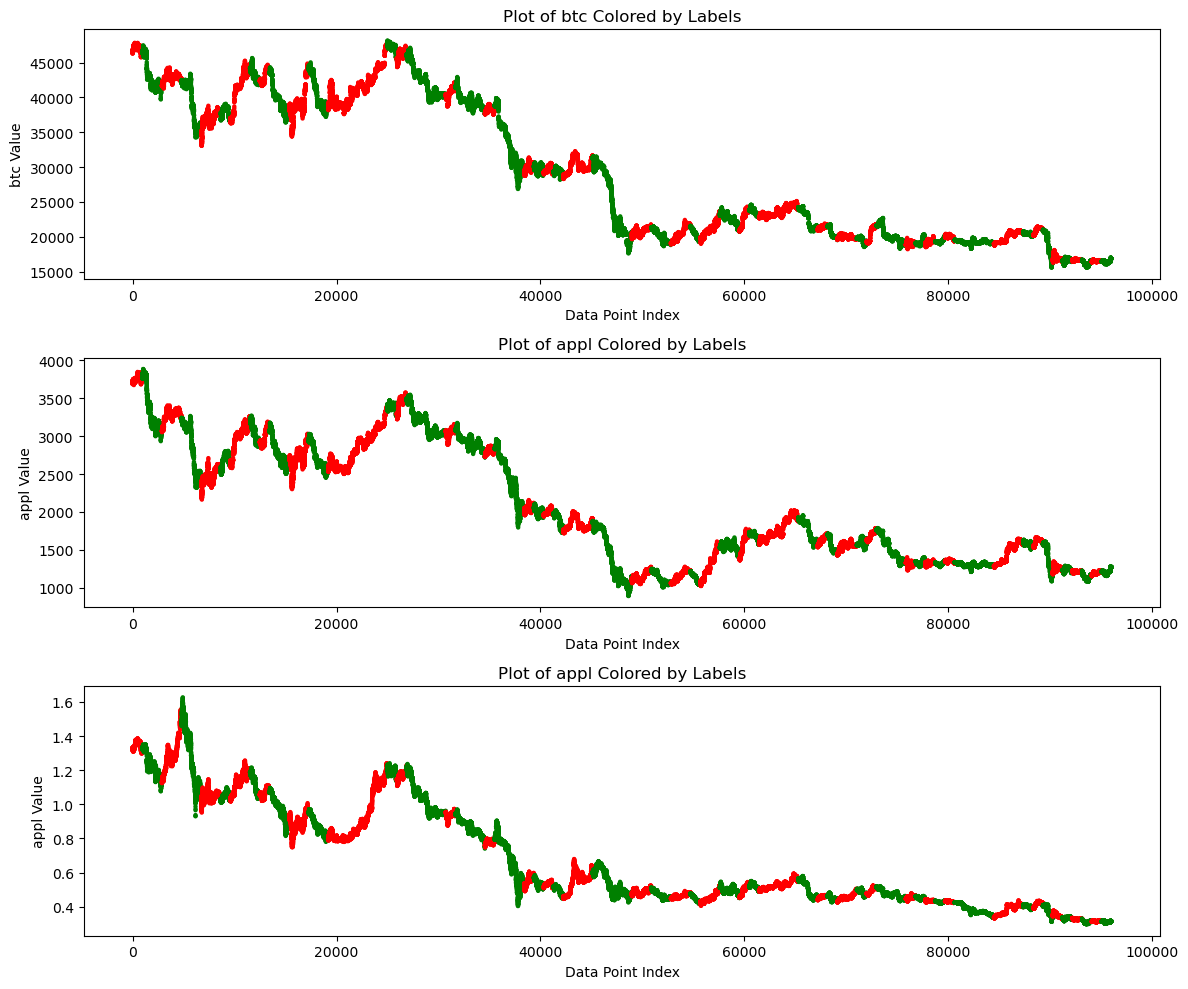

In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Assuming initial_preds_rep is already defined and repeated correctly
a,qe,_ = best_gsomm.predict(train_matrix1)

initial_preds_rep = np.repeat(np.array(a).flatten(), 10*96)


# Assuming eth and btc data are already extracted
btc = resampled_data1.values[:96000, 0]
eth = resampled_data2.values[:96000, 0]
ada = resampled_data3.values[:96000, 0]


# Define the custom colormap: red, blue, and green for your mapped labels
custom_cmap = ListedColormap(['green', 'red'])

# Create figure with two subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 10))

# Plot ETH in the top subplot
axs[0].scatter(np.arange(len(btc[:96000])), btc[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[0].set_title('Plot of btc Colored by Labels')
axs[0].set_xlabel('Data Point Index')
axs[0].set_ylabel('btc Value')

# Plot BTC in the bottom subplot
axs[1].scatter(np.arange(len(eth[:96000])), eth[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[1].set_title('Plot of appl Colored by Labels')
axs[1].set_xlabel('Data Point Index')
axs[1].set_ylabel('appl Value')

# Plot BTC in the bottom subplot
axs[2].scatter(np.arange(len(ada[:96000])), ada[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[2].set_title('Plot of appl Colored by Labels')
axs[2].set_xlabel('Data Point Index')
axs[2].set_ylabel('appl Value')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


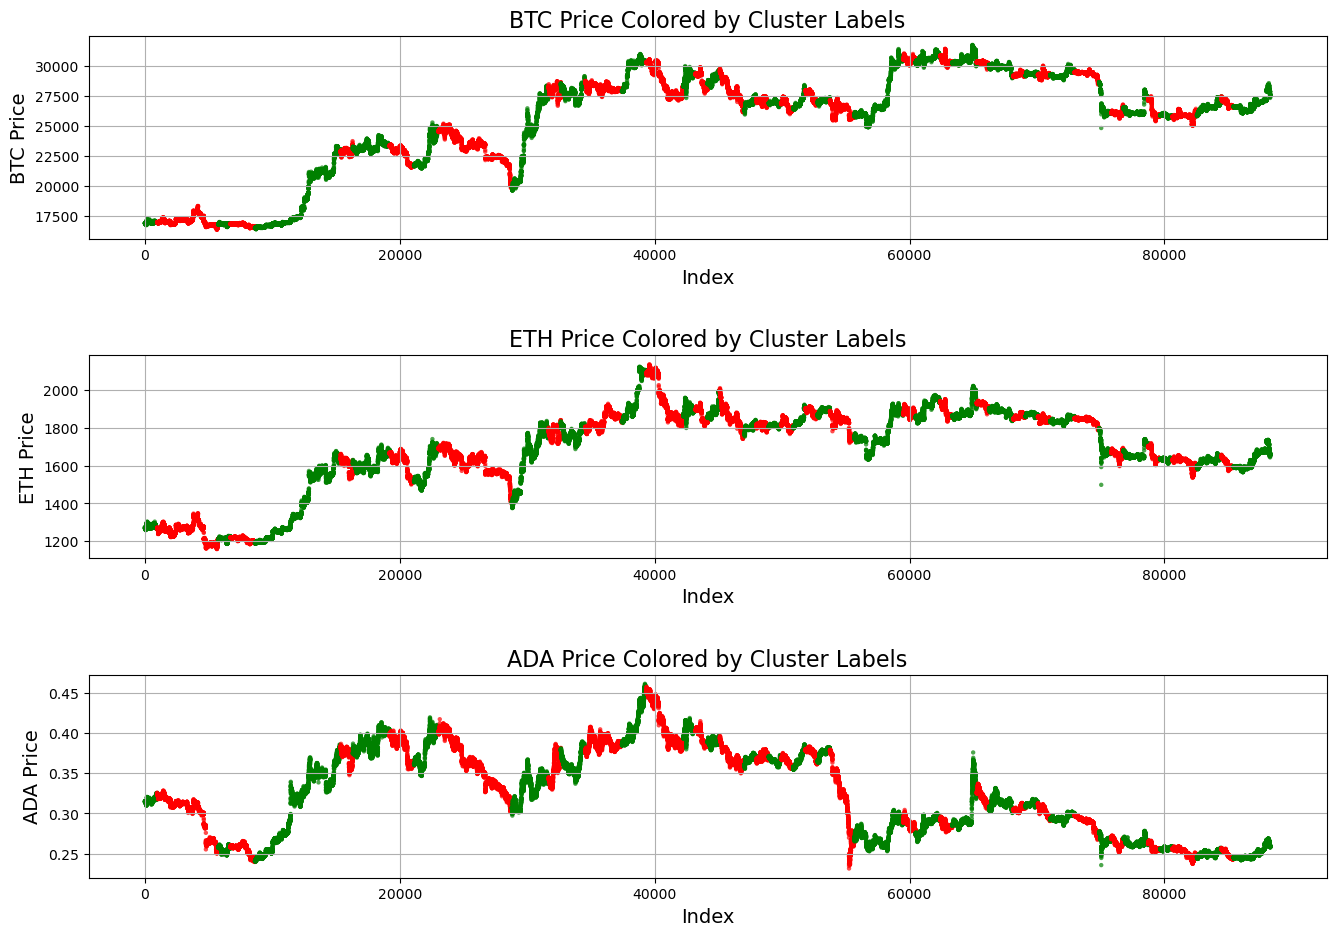

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# Step 3: Get predictions and quantization error
test_preds, qe, proto = best_gsomm.predict(test_matrix)  # Replace 'gsomm.predict' with your method
test_preds = np.array(test_preds).flatten()
initial_preds_rep = np.repeat(test_preds, 10*96)
initial_preds_rep.shape



# Assuming eth, btc, and ada data are already extracted
btc = resampled_data1.values[96000:, 0]
eth = resampled_data2.values[96000:, 0]
ada = resampled_data3.values[96000:, 0]

# Define the custom colormap: green for one label, red for the other
custom_cmap = ListedColormap(['red', 'green'])

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(14, 10))  # Increased figure size

# Plot BTC in the first subplot
axs[0].scatter(np.arange(len(btc[:88320])), btc[:88320],
               c=initial_preds_rep[:], cmap=custom_cmap, s=10, alpha=0.7, edgecolor='none')
axs[0].set_title('BTC Price Colored by Cluster Labels', fontsize=16)
axs[0].set_xlabel('Index', fontsize=14)
axs[0].set_ylabel('BTC Price', fontsize=14)
axs[0].grid(True)  # Add grid

# Plot ETH in the second subplot
axs[1].scatter(np.arange(len(eth[:88320])), eth[:88320],
               c=initial_preds_rep[:], cmap=custom_cmap, s=10, alpha=0.7, edgecolor='none')
axs[1].set_title('ETH Price Colored by Cluster Labels', fontsize=16)
axs[1].set_xlabel('Index', fontsize=14)
axs[1].set_ylabel('ETH Price', fontsize=14)
axs[1].grid(True)  # Add grid

# Plot ADA in the third subplot
axs[2].scatter(np.arange(len(ada[:88320])), ada[:88320],
               c=initial_preds_rep[:], cmap=custom_cmap, s=10, alpha=0.7, edgecolor='none')
axs[2].set_title('ADA Price Colored by Cluster Labels', fontsize=16)
axs[2].set_xlabel('Index', fontsize=14)
axs[2].set_ylabel('ADA Price', fontsize=14)
axs[2].grid(True)  # Add grid

# Improve layout and add padding
plt.tight_layout(pad=3.0)
plt.savefig("Multivariate_Crypto.png")
# Show the plot
plt.show()


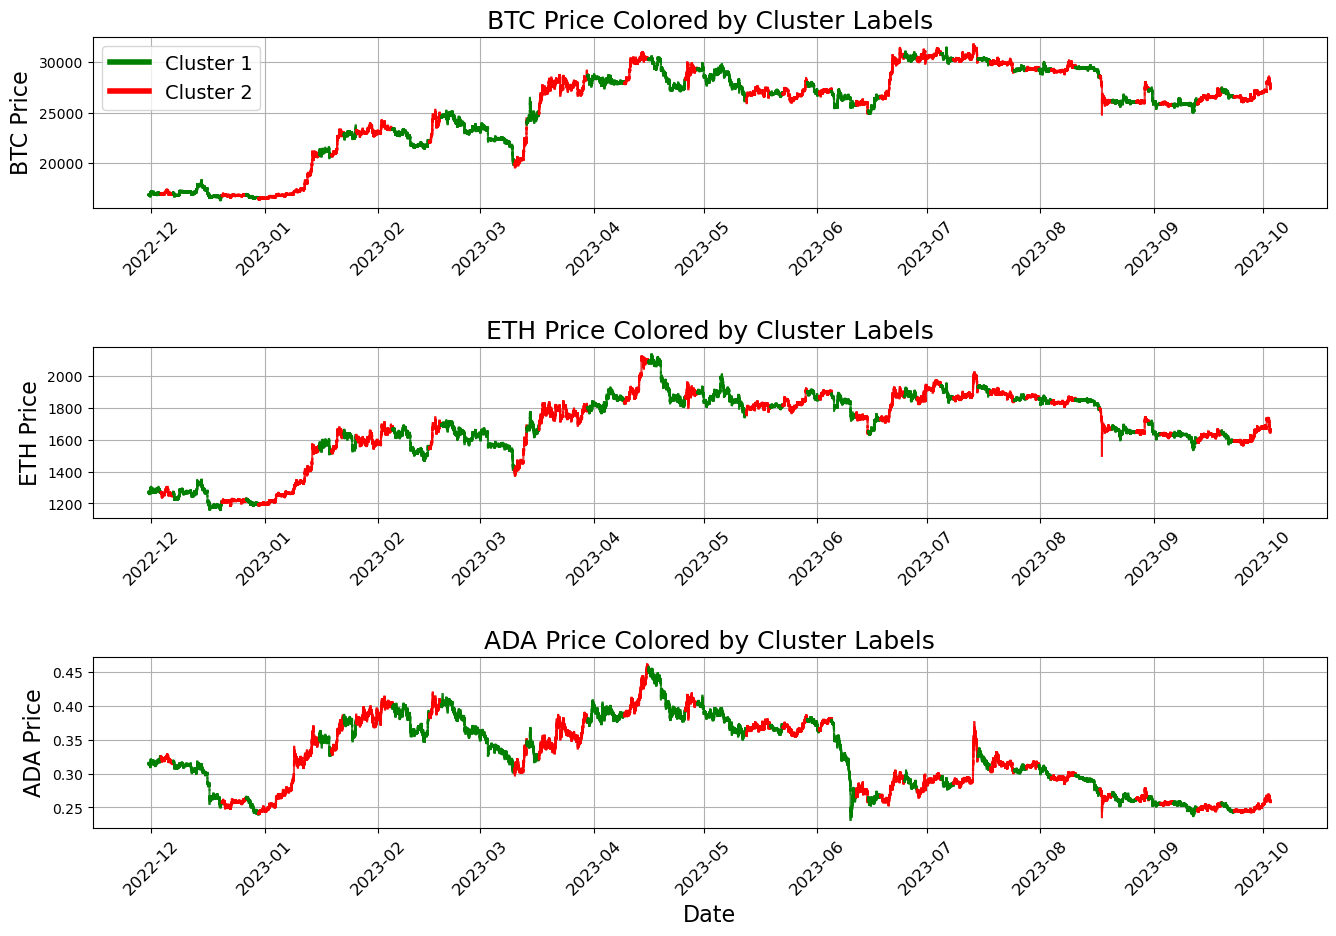

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D  # For creating custom legend entries

# Assuming scalers, gsomm, and resampled data are already defined
scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# Step 3: Get predictions and quantization error
test_preds, qe, proto = gsomm.predict(test_matrix)  # Replace 'gsomm.predict' with your method
test_preds = np.array(test_preds).flatten()
initial_preds_rep = np.repeat(test_preds, 10 * 96)
initial_preds_rep.shape

# Assuming eth, btc, and ada data are already extracted
btc = resampled_data1.values[96000:, 0]
eth = resampled_data2.values[96000:, 0]
ada = resampled_data3.values[96000:, 0]

# Get the actual date-times from `resampled_data1`
btc_dates = resampled_data1.index[96000:96000 + 88320]  # Extract the corresponding date-times

# Define the custom colormap: green for one label, red for the other
custom_cmap = ListedColormap(['red', 'green'])

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(14, 10))  # Increased figure size

# Plot BTC as lines
axs[0].plot(btc_dates, btc[:88320], color='gray', alpha=0.4)  # Plot entire BTC data in light color
for i in range(len(btc[:88320]) - 1):
    axs[0].plot([btc_dates[i], btc_dates[i + 1]], [btc[i], btc[i + 1]], color=custom_cmap(initial_preds_rep[i]), alpha=0.7)

# Set title and labels for BTC
axs[0].set_title('BTC Price Colored by Cluster Labels', fontsize=18)
axs[0].set_ylabel('BTC Price', fontsize=16)
axs[0].grid(True)

# Plot ETH as lines
axs[1].plot(btc_dates, eth[:88320], color='gray', alpha=0.4)  # Plot entire ETH data in light color
for i in range(len(eth[:88320]) - 1):
    axs[1].plot([btc_dates[i], btc_dates[i + 1]], [eth[i], eth[i + 1]], color=custom_cmap(initial_preds_rep[i]), alpha=0.7)

# Set title and labels for ETH
axs[1].set_title('ETH Price Colored by Cluster Labels', fontsize=18)
axs[1].set_ylabel('ETH Price', fontsize=16)
axs[1].grid(True)

# Plot ADA as lines
axs[2].plot(btc_dates, ada[:88320], color='gray', alpha=0.4)  # Plot entire ADA data in light color
for i in range(len(ada[:88320]) - 1):
    axs[2].plot([btc_dates[i], btc_dates[i + 1]], [ada[i], ada[i + 1]], color=custom_cmap(initial_preds_rep[i]), alpha=0.7)

# Set title and labels for ADA
axs[2].set_title('ADA Price Colored by Cluster Labels', fontsize=18)
axs[2].set_xlabel('Date', fontsize=16)
axs[2].set_ylabel('ADA Price', fontsize=16)
axs[2].grid(True)

# Create custom legend entries
legend_elements = [Line2D([0], [0], color='green', lw=4, label='Cluster 1'),
                   Line2D([0], [0], color='red', lw=4, label='Cluster 2')]

# Add the legend to the top subplot (or you can add it to a different subplot)
axs[0].legend(handles=legend_elements, loc='upper left', fontsize=14)

# Format the x-axis to show dates nicely on all subplots
for ax in axs:
    ax.xaxis.set_tick_params(labelsize=12)  # Ensure x-axis labels are visible
    ax.tick_params(axis='x', rotation=45)   # Rotate the date labels for better readability

# Improve layout and add padding
plt.tight_layout(pad=3.0)

# Save the figure
output_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Pictures for Report\Multivariate_Crypto.png"
plt.savefig(output_path)

# Show the plot
plt.show()
